# Imports

In [1]:
import glob
import pandas as pd
import folium
from folium.plugins import MarkerCluster
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import json
from folium.plugins import TimestampedGeoJson

# Get Coordinates

In [ ]:
# Load first row per CSV
files = glob.glob("data/*.csv")
records = []

for f in files:
    df_tmp = pd.read_csv(f, nrows=1)
    df_tmp["_source"] = os.path.basename(f)

    # Determine group based on filename prefix
    fname = df_tmp["_source"].iloc[0]
    if fname.startswith("Hygro"):
        df_tmp["_group"] = "Hygro"
    elif fname.startswith("HYDRORANGER"):
        df_tmp["_group"] = "HYDRORANGER"
    elif fname.startswith("Droplet"):
        df_tmp["_group"] = "Droplet"
    elif fname.startswith("THETA"):
        df_tmp["_group"] = "THETA"
    elif fname.startswith("ECHO"):
        df_tmp["_group"] = "ECHO"
    else:
        df_tmp["_group"] = "Other"

    records.append(df_tmp)

df = pd.concat(records, ignore_index=True)

# Clean latitude/longitude
df = df.dropna(subset=["latitude", "longitude"])
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df = df.dropna(subset=["latitude", "longitude"])

# Downloaded Map of Scotland

curl -L "https://services1.arcgis.com/ESMARspQHYMw9BZ9/arcgis/rest/services/Counties_and_Unitary_Authorities_May_2023_UK_BGC/FeatureServer/0/query?where=1=1&outFields=*&f=geojson" -o counties.geojson

curl -L "https://services1.arcgis.com/ESMARspQHYMw9BZ9/arcgis/rest/services/Scottish_Parliamentary_Regions_December_2022_SC_BUC/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson" -o scotland-counties.geojson

In [86]:
scotland = gpd.read_file("maps/scotland-counties.geojson").to_crs(epsg=4326)

# Convert GeoDataFrame to GeoJSON
scotland_geojson = json.loads(scotland.to_json())

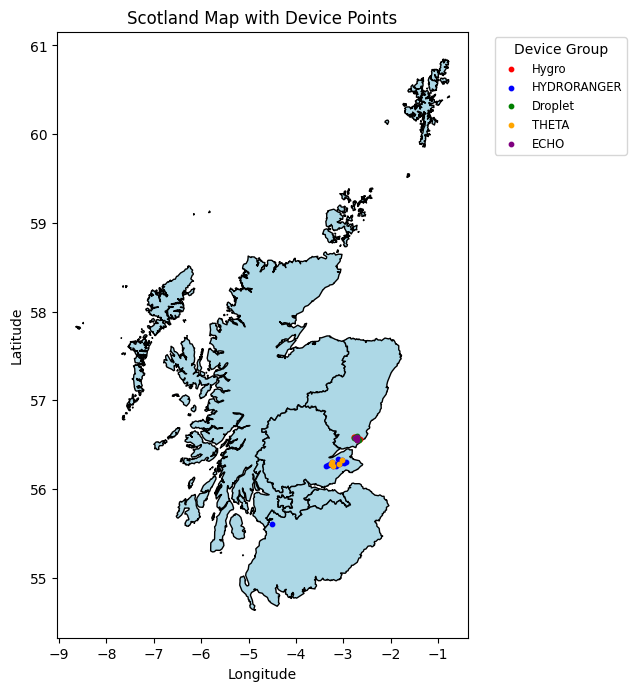

In [87]:
# Define colors for each group
group_colors = {
    "Hygro": "red",
    "HYDRORANGER": "blue",
    "Droplet": "green",
    "THETA": "orange",
    "ECHO": "purple",
    "Other": "gray"
}

# Start figure
fig, ax = plt.subplots(figsize=(6, 8))
ax.set_aspect('equal')

# Plot Scotland
scotland.plot(ax=ax, edgecolor='black', facecolor='lightblue')

# Plot points with assigned colors
for group, color in group_colors.items():
    subset = df[df["_group"] == group]
    if not subset.empty:
        ax.scatter(subset["longitude"], subset["latitude"], color=color, s=10, label=group, zorder=5)

# Legend
ax.legend(title="Device Group", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")

# Labels and title
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Scotland Map with Device Points")

plt.tight_layout()
plt.show()

# Folium Map HTML

In [ ]:
# Center roughly on Scotland
m = folium.Map(location=[56.5, -4], zoom_start=6)

# Add Scotland polygons
folium.GeoJson(
    scotland_geojson,
    name="Scotland Borders",
    style_function=lambda feature: {
        "fillColor": "lightblue",
        "color": "black",
        "weight": 1,
        "fillOpacity": 0.3,
    }
).add_to(m)

# Define colors for groups
group_colors = {
    "Hygro": "red",
    "HYDRORANGER": "blue",
    "Droplet": "green",
    "THETA": "orange",
    "ECHO": "purple",
    "Other": "gray"
}

# Add points as FeatureGroups
for group, color in group_colors.items():
    fg = folium.FeatureGroup(name=group)
    subset = df[df["_group"] == group]
    for _, row in subset.iterrows():
        folium.CircleMarker(
            location=[row["latitude"], row["longitude"]],
            radius=5,
            color=color,
            fill=True,
            fill_opacity=0.7,
            popup=f"{row['_group']}<br>{row['device_name']}"
        ).add_to(fg)
    fg.add_to(m)

# Add layer control
folium.LayerControl(collapsed=False).add_to(m)

# Get bounds from points + Scotland polygons
all_lats = list(df["latitude"]) + list(scotland.geometry.centroid.y)
all_lons = list(df["longitude"]) + list(scotland.geometry.centroid.x)
m.fit_bounds([[min(all_lats), min(all_lons)], [max(all_lats), max(all_lons)]])

# Save map
m.save("scotland_map.html")
print("Saved to scotland_map.html")

Saved to scotland_map.html


/var/folders/cv/pl7pkxf95qj4jz9bmqwf6f8h0000gp/T/ipykernel_44104/1754346092.py:59: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  all_lats = list(df["latitude"]) + list(scotland.geometry.centroid.y)
/var/folders/cv/pl7pkxf95qj4jz9bmqwf6f8h0000gp/T/ipykernel_44104/1754346092.py:60: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  all_lons = list(df["longitude"]) + list(scotland.geometry.centroid.x)


In [ ]:
# --------------------------
# 1️⃣ Load ALL rows from all CSVs
# --------------------------
files = glob.glob("data/*.csv")
records = []

for f in files:
    df_tmp = pd.read_csv(f, nrows=5000)

    # Add filename so we know which device it came from
    df_tmp["_source"] = os.path.basename(f)

    # Determine group based on filename prefix
    fname = df_tmp["_source"].iloc[0]
    if fname.startswith("Hygro"):
        df_tmp["_group"] = "Hygro"
    elif fname.startswith("HYDRORANGER"):
        df_tmp["_group"] = "HYDRORANGER"
    elif fname.startswith("Droplet"):
        df_tmp["_group"] = "Droplet"
    elif fname.startswith("THETA"):
        df_tmp["_group"] = "THETA"
    elif fname.startswith("ECHO"):
        df_tmp["_group"] = "ECHO"
    else:
        df_tmp["_group"] = "Other"

    records.append(df_tmp)

df = pd.concat(records, ignore_index=True)

# --------------------------
# 2️⃣ Clean latitude/longitude/timestamps
# --------------------------
df = df.dropna(subset=["latitude", "longitude"])
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df = df.dropna(subset=["latitude", "longitude"])

# Convert timestamps to ISO 8601 (required for animation)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp"])
df["timestamp"] = df["timestamp"].dt.strftime("%Y-%m-%dT%H:%M:%S")

# --------------------------
# 3️⃣ Load Scotland GeoJSON
# --------------------------
scotland = gpd.read_file("maps/scotland-counties.geojson")
scotland = scotland.to_crs(epsg=4326)

# Convert to Python dict for folium
scotland_geojson = scotland.__geo_interface__

# --------------------------
# 4️⃣ Build Folium Base Map
# --------------------------
m = folium.Map(location=[56.5, -4], zoom_start=7, tiles="cartodbpositron")

# Draw Scotland boundaries
folium.GeoJson(
    scotland_geojson,
    name="Scotland",
    style_function=lambda feature: {
        "fillColor": "lightblue",
        "color": "black",
        "weight": 1,
        "fillOpacity": 0.25,
    }
).add_to(m)

# --------------------------
# 5️⃣ Time animation layer
# --------------------------

colors = {
    "Hygro": "red",
    "HYDRORANGER": "blue",
    "Droplet": "green",
    "THETA": "orange",
    "ECHO": "purple",
    "Other": "gray"
}

features = []

for _, row in df.iterrows():
    features.append({
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [row["longitude"], row["latitude"]],
        },
        "properties": {
            "time": row["timestamp"],
            "style": {"color": colors[row["_group"]]},
            "icon": "circle",
            "iconstyle": {
                "fillColor": colors[row["_group"]],
                "fillOpacity": 0.9,
                "stroke": True,
                "radius": 6
            },
            "popup": f"{row['_group']}<br>{row['device_name']}<br>{row['timestamp']}"
        },
    })

geojson_data = {"type": "FeatureCollection", "features": features}

TimestampedGeoJson(
    geojson_data,
    transition_time=300,
    loop=False,
    auto_play=False,
    period="PT15M"   # interpret time steps as 1 hour (adjust if needed)
).add_to(m)

# --------------------------
# 6️⃣ Auto-fit to Scotland
# --------------------------
all_lats = list(df["latitude"]) + list(scotland.centroid.y)
all_lons = list(df["longitude"]) + list(scotland.centroid.x)

m.fit_bounds([[min(all_lats), min(all_lons)],
              [max(all_lats), max(all_lons)]])

# --------------------------
# 7️⃣ Save map
# --------------------------
m.save("../maps/scotland_timeslider_full2.html")
print("Saved to scotland_timeslider_full2.html")

/var/folders/cv/pl7pkxf95qj4jz9bmqwf6f8h0000gp/T/ipykernel_9018/605480751.py:120: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  all_lats = list(df["latitude"]) + list(scotland.centroid.y)
/var/folders/cv/pl7pkxf95qj4jz9bmqwf6f8h0000gp/T/ipykernel_9018/605480751.py:121: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  all_lons = list(df["longitude"]) + list(scotland.centroid.x)


Saved to scotland_timeslider_full2.html
